In [1]:
import numpy as np
from tqdm import tqdm, trange
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.nn import CrossEntropyLoss
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
from torchvision.datasets.mnist import MNIST
np.random.seed(0)
torch.manual_seed(0)

import matplotlib.pyplot as plt


tensor(7)
torch.Size([256, 1, 28, 28])
torch.Size([256])
torch.Size([256, 49, 16])
0.08304715156555176


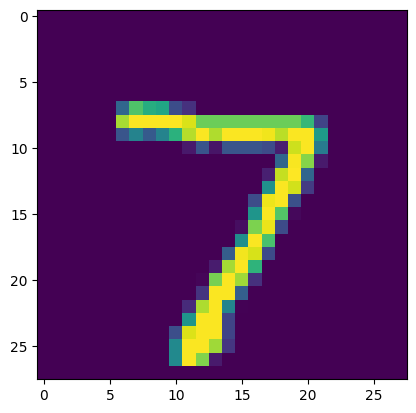

In [2]:
import time 
def patchify_tommy(images, n_patches):
    n_batch, c, h, w = images.shape
    patch_size_y, patch_size_x = h//n_patches, w//n_patches
    patches = torch.zeros((n_batch, n_patches ** 2,  h * w * c // n_patches ** 2))
    for idx, image in enumerate(images):
        c_patch=0
        for i in range(n_patches):
            for j in range(n_patches):
                pos_h_st = int(i * patch_size_y)
                pos_h_end = int((i + 1) * patch_size_y)
                pos_w_st = int(j * patch_size_x)
                pos_w_end = int((j + 1) * patch_size_x)
                patches[idx, c_patch , :] = image[:, pos_h_st: pos_h_end, pos_w_st: pos_w_end] .flatten()  
                c_patch+=1
    return patches

transform = ToTensor()
test_set = MNIST(root='./../datasets', train=False, download=True, transform=transform)
test_loader = DataLoader(test_set, shuffle=False, batch_size=256)
st_count=0
for batch in test_loader:
    x, y = batch
    img = x[0,0,:,:].cpu().detach().numpy()
    plt.imshow(img)
    print(y[0])
    print(x.shape)
    print(y.shape)
    st = time.time()
    patches = patchify_tommy(x, n_patches=7)
    print(patches.shape)
    st_count += time.time()-st
    break
print(st_count)

In [3]:
rnn = nn.GRU(10, 20, 2)
input = torch.randn(5, 3, 10)
h0 = torch.randn(2, 3, 20)
output, hn = rnn(input, h0)
print(output.shape)
print(hn.shape)

torch.Size([5, 3, 20])
torch.Size([2, 3, 20])


In [14]:
class MultiHeadAttentation(nn.Module):
    def __init__(self, d, n_heads=2):
        super(MultiHeadAttentation, self).__init__()
        self.d = d
        self.n_heads = n_heads
        self.q_mappings = nn.ModuleList([nn.Linear(d, d) for _ in range(self.n_heads)])
        self.k_mappings = nn.ModuleList([nn.Linear(d, d) for _ in range(self.n_heads)])
        self.v_mappings = nn.ModuleList([nn.Linear(d, d) for _ in range(self.n_heads)])
        self.o_mappings = nn.Linear(d*n_heads, d)
        self.softmax = nn.Softmax(dim=-1)
    def forward(self, sequences):
        # Sequences has shape (N, seq_length, token_dim)
        # We go into shape    (N, seq_length, n_heads, token_dim / n_heads)
        # And come back to    (N, seq_length, item_dim)  (through concatenation)
        result_head = []
        # multi-head
        for head in range(self.n_heads):
            q_mapping = self.q_mappings[head]
            k_mapping = self.k_mappings[head]
            v_mapping = self.v_mappings[head]
    
            q, k, v = q_mapping(sequences), k_mapping(sequences), v_mapping(sequences)
            print("q, k: ", q.shape, k.shape)
            #k = torch.transpose(k, 1, 2)
            #print("k2: ", k.shape)
            q = torch.transpose(q, 1, 2)
            print("q2: ", q.shape)
            a=torch.matmul(q,k)
            attention = self.softmax(a / (self.d ** 0.5))
            print("attention: ", attention.shape)
            #o=torch.matmul(attention,v)
            o=torch.matmul(v,attention)
            result_head.append(o)
        
        print("result_head: ", len(result_head))
        o = torch.cat(result_head,axis=-1)
        print("output1: ", o.shape)
        o = self.o_mappings(o)
        print("output2: ", o.shape)
        
        return o

In [15]:
hidden_d=1024
n_heads=4
mha = MultiHeadAttentation(hidden_d, n_heads)
input = torch.randn(64, 30, 1024)
output = mha(input)
print(output.shape)


q, k:  torch.Size([64, 30, 1024]) torch.Size([64, 30, 1024])
q2:  torch.Size([64, 1024, 30])
attention:  torch.Size([64, 1024, 1024])
q, k:  torch.Size([64, 30, 1024]) torch.Size([64, 30, 1024])
q2:  torch.Size([64, 1024, 30])
attention:  torch.Size([64, 1024, 1024])
q, k:  torch.Size([64, 30, 1024]) torch.Size([64, 30, 1024])
q2:  torch.Size([64, 1024, 30])
attention:  torch.Size([64, 1024, 1024])
q, k:  torch.Size([64, 30, 1024]) torch.Size([64, 30, 1024])
q2:  torch.Size([64, 1024, 30])
attention:  torch.Size([64, 1024, 1024])
result_head:  4
output1:  torch.Size([64, 30, 4096])
output2:  torch.Size([64, 30, 1024])
torch.Size([64, 30, 1024])


In [24]:
class_token = nn.Parameter(torch.rand(1, hidden_d))
print(class_token.shape)
input = torch.randn(64, 30, 1024)
output = class_token(input)
print(output.shape)

torch.Size([1, 1024])


TypeError: 'Parameter' object is not callable

In [2]:
import torch
def get_positional_embeddings(sequence_length, d):
        result = torch.ones(sequence_length, d)
        for i in range(sequence_length):
            for j in range(d):
                result[i][j] = np.sin(i / (10000 ** (j / d))) if j % 2 == 0 else np.cos(i / (10000 ** ((j - 1) / d)))
        return result
    
a = get_positional_embeddings(1024, 30)
print(a.shape)

ModuleNotFoundError: No module named 'torch'

In [1]:
import os
import numpy as np
import csv

def read_train_data(file_name):
    with open(file_name, 'r', newline='') as f:
        lines = csv.reader(f)
        data = []
        for line in lines:
            data.append(line)

    new_data = np.array(data).astype(np.float64)
    return new_data

def check_file_size(directory, target_shape):
    for filename in os.listdir(directory):
        filepath = os.path.join(directory, filename)
        if os.path.isfile(filepath):
            # Assuming the file is in a format that can be read as an array (e.g., .npy)
            try:
                #array = np.load(filepath)
                array = read_train_data(filepath)
                if array.shape != target_shape:
                    print(f"Filename {filename} does not conform to the target shape {target_shape}, it was {array.shape}")
                    os.remove(filepath)
            except:
                print(f"Could not read file {filename}")

# Path to the directory containing the files you want to check
directory_path = './MetaPreTrain/Lane_keeping/3_ICA/'

# Target shape to check
target_shape = (30, 1024)

# Check files in the directory
check_file_size(directory_path, target_shape)